In [1]:
#import numpy as np
import pandas as pd

from neuralforecast import NeuralForecast
import sys
import os
sys.path.append(os.path.abspath("../../"))
from QNeuralForecast.dlinear import QDLinear
# from QNeuralForecast.nhits import NHITS
# from QNeuralForecast.patchtst import PatchTST
# from QNeuralForecast.timesnet import TimesNet
from neuralforecast.models import DLinear, NHITS, PatchTST, TimesNet
# from neuralforecast.losses.pytorch import MAE
# from torch.optim import Adam

/Users/i588313/Library/Python/3.11/lib/python/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.24.3 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


In [2]:
df = pd.read_csv("../data/train_prepared.csv", parse_dates=["Date"], low_memory=False)

df = df.sort_values(["Store","Date"])

split_date = "2015-06-01"

train_df = df[df["Date"] < split_date].copy()
val_df   = df[df["Date"] >= split_date].copy()

In [3]:
HORIZON=52
INPUT_SIZE=60
#OPTIMIZER=Adam() # <-- TODO: specify list of params
MAX_STEPS=300
SCALER_TYPE="standard"

dlinear = DLinear(
    h=HORIZON,
    input_size=INPUT_SIZE,
    max_steps=MAX_STEPS,
    scaler_type=SCALER_TYPE,
    #optimizer=OPTIMIZER
)
qdlinear = QDLinear(
    h=HORIZON,
    input_size=INPUT_SIZE,
    max_steps=MAX_STEPS,
    scaler_type=SCALER_TYPE,
    #optimizer=OPTIMIZER
)
nhits = NHITS(
    h=HORIZON,
    input_size=INPUT_SIZE,
    max_steps=MAX_STEPS,
    scaler_type=SCALER_TYPE,
    #optimizer=OPTIMIZER,
)
patchtst = PatchTST(
    h=HORIZON,
    input_size=INPUT_SIZE,
    max_steps=MAX_STEPS,
    scaler_type=SCALER_TYPE,
    #optimizer=OPTIMIZER,
)
timesnet = TimesNet(
    h=HORIZON,
    input_size=INPUT_SIZE,
    max_steps=MAX_STEPS,
    scaler_type=SCALER_TYPE,
    #optimizer=OPTIMIZER,
)

Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1


In [10]:
# nf = NeuralForecast(models=[dlinear,nhits,patchtst,timesnet], freq="D")
nf = NeuralForecast(models=[qdlinear], freq="D")

In [11]:
nf.fit(train_df,
       id_col="Store",
       time_col="Date",
       target_col="Sales",
       verbose=True,
       distributed_config=None)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE               │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d     │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm      │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp      │      0 │ train │     0 │
│ 4 │ linear_trend  │ QuantumProjection │    528 │ train │     0 │
│ 5 │ linear_season │ QuantumProjection │    528 │ train │     0 │
└───┴───────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 1.1 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.1 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_steps=300` reached.


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

Models found: ['index', 'QDLinear']

Global MAE per model:
QDLinear: 1572.0601
index: 22845.6394

Top 5 Stores (Best Predicted on Average): [112, 83, 103, 113, 48]


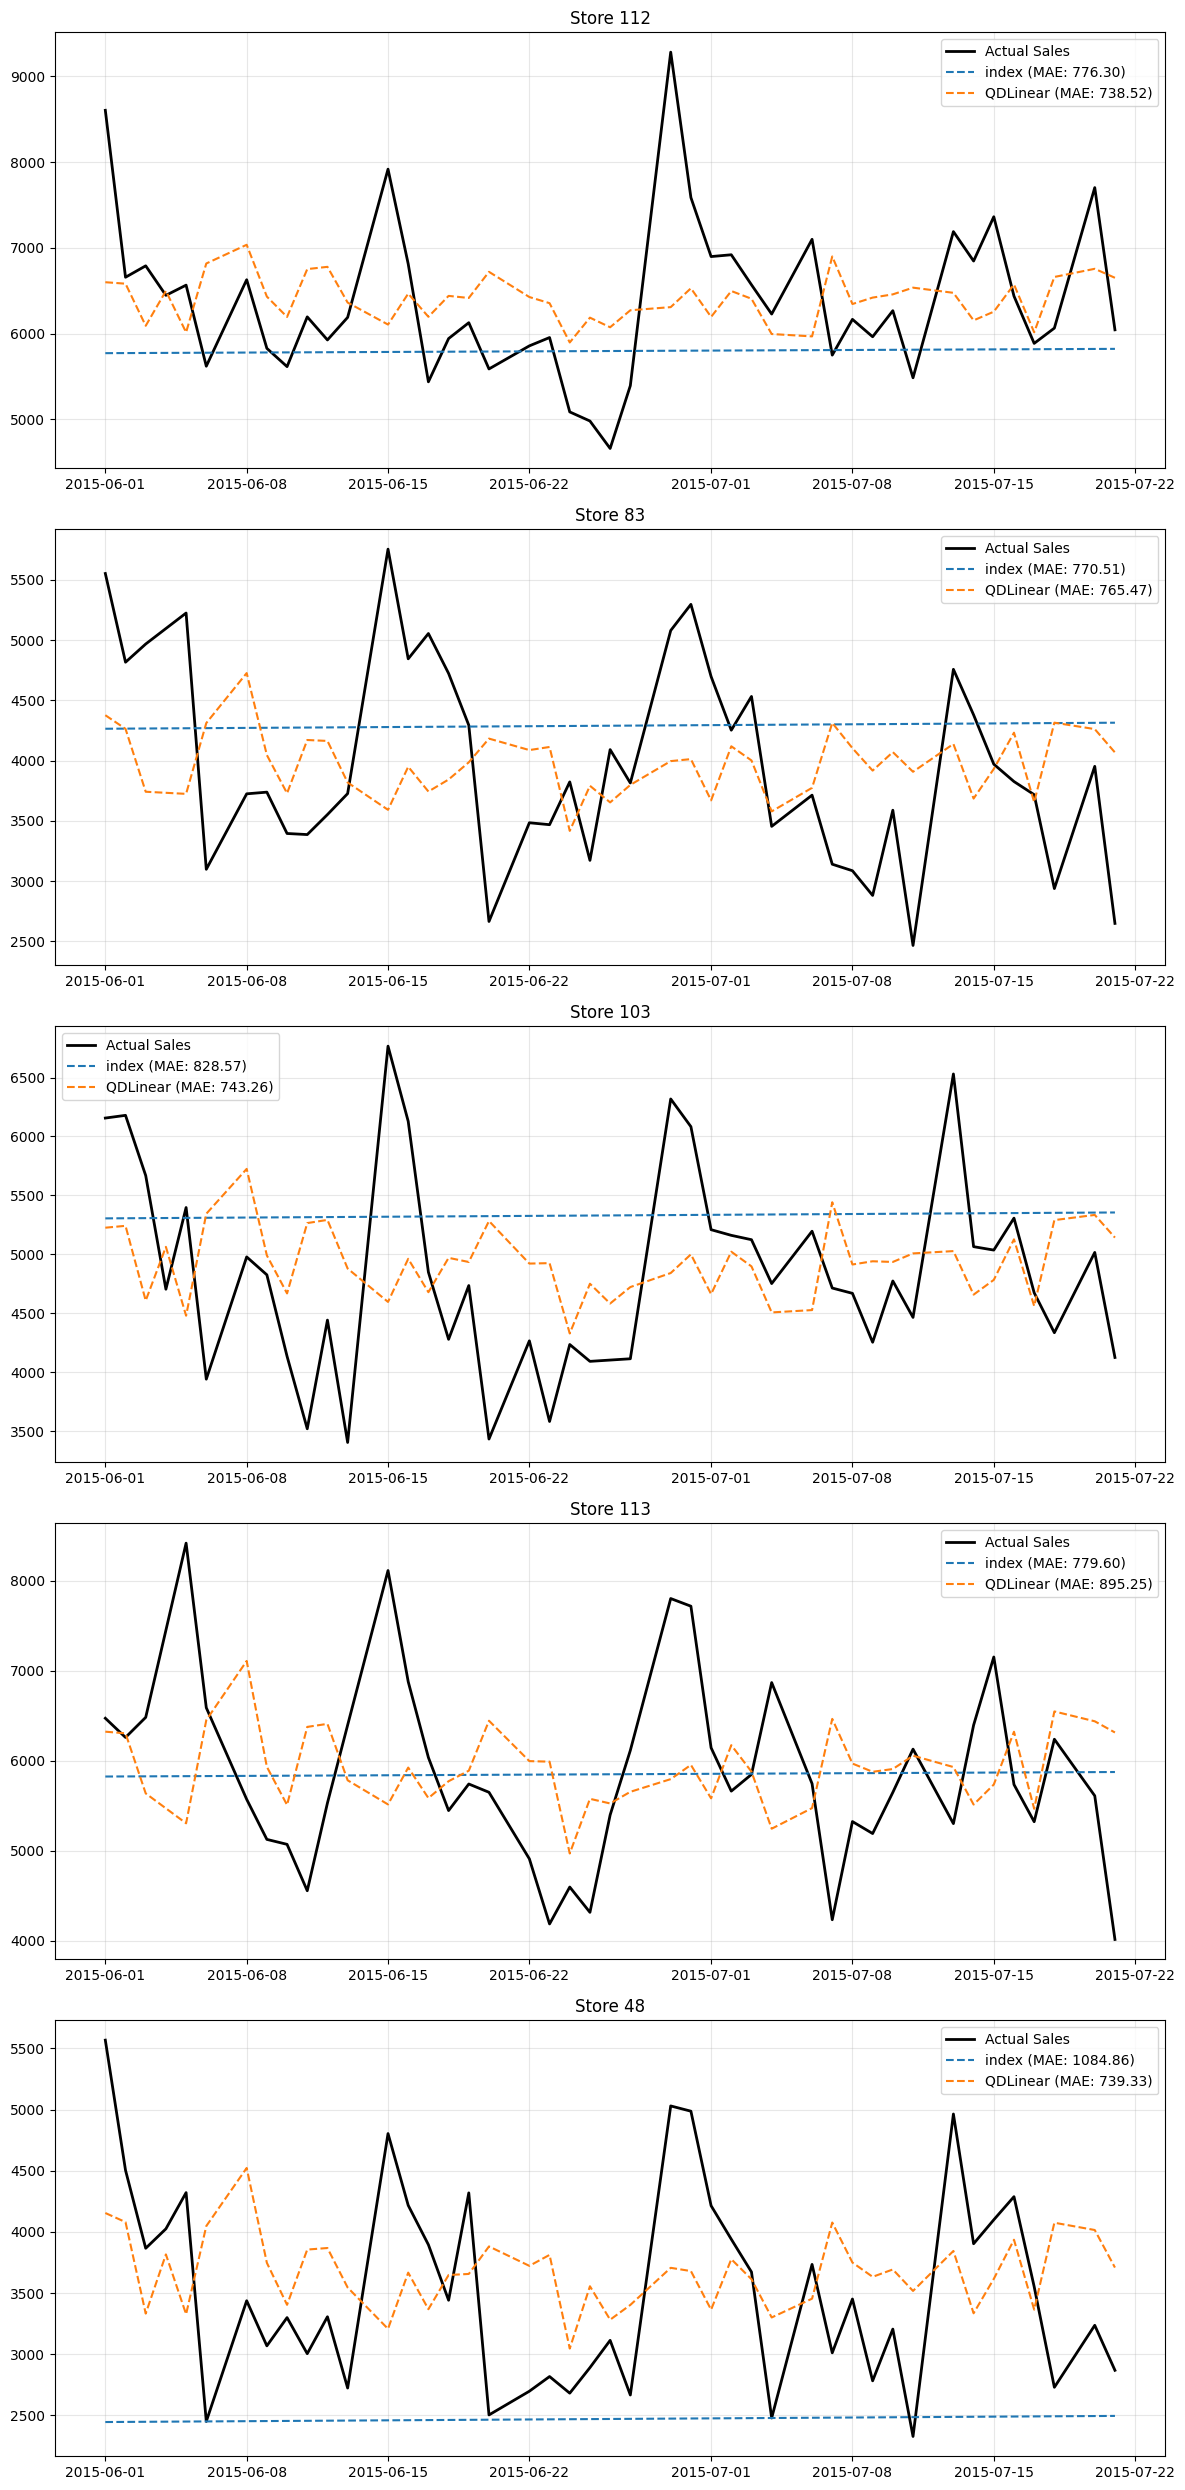

In [12]:
# Predict with all models
forecasts = nf.predict().reset_index()

# Merge with validation values to compare
comparison = val_df[["Store", "Date", "Sales"]].merge(forecasts, on=["Store", "Date"], how="inner")

# Identify the model columns (exclude Store, Date, and Sales if it somehow got in there)
model_names = [col for col in forecasts.columns if col not in ["Store", "Date"]]
print(f"Models found: {model_names}")

# Calculate separate MAE for each model
results = {}
for model in model_names:
    mae = (comparison["Sales"] - comparison[model]).abs().mean()
    results[model] = mae

print("\nGlobal MAE per model:")
for m, score in sorted(results.items(), key=lambda x: x[1]):
    print(f"{m}: {score:.4f}")

# Find Top 5 Best Predicted Stores (using average error across all models)
comparison["avg_model_error"] = 0
for model in model_names:
    comparison["avg_model_error"] += (comparison["Sales"] - comparison[model]).abs()
comparison["avg_model_error"] /= len(model_names)

mae_per_store = comparison.groupby("Store")["avg_model_error"].mean().sort_values()
top_5_stores = mae_per_store.head(5).index.tolist()

print(f"\nTop 5 Stores (Best Predicted on Average): {top_5_stores}")

import matplotlib.pyplot as plt

# Plot for the top 5 stores
fig, axes = plt.subplots(5, 1, figsize=(12, 25), sharex=False)

for i, store_id in enumerate(top_5_stores):
    store_data = comparison[comparison["Store"] == store_id]
    
    ax = axes[i]
    # Plot Actual
    ax.plot(store_data["Date"], store_data["Sales"], label="Actual Sales", color='black', linewidth=2)
    
    # Plot each model
    for model in model_names:
        model_mae = (store_data["Sales"] - store_data[model]).abs().mean()
        ax.plot(store_data["Date"], store_data[model], label=f"{model} (MAE: {model_mae:.2f})", linestyle='--')
    
    ax.set_title(f"Store {store_id}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
forecasts

,index,Store,Date,DLinear,QDLinear
0,0,1,2015-05-31,4695.095215,4290.990234
1,1,1,2015-06-01,4834.953125,5004.865234
2,2,1,2015-06-02,5223.577637,4873.798828
3,3,1,2015-06-03,5003.821289,4098.610352
4,4,1,2015-06-04,4440.795898,4526.705566
...,...,...,...,...,...
57975,57975,1115,2015-07-17,6399.927246,6640.035156
57976,57976,1115,2015-07-18,8427.583008,8366.679688
57977,57977,1115,2015-07-19,8033.466309,6800.257812
57978,57978,1115,2015-07-20,7450.992188,8011.272949
